# To Do:

- convert gb to tb
- combine 2 stacked bar plots into one figure for report

In [1]:
import pandas as pd
import numpy as np
from netCDF4 import Dataset
import matplotlib
import matplotlib.pyplot as plt
#import plottingHelpersIris as ph
import copy
matplotlib.rc('text', usetex=False)

fs = 33

matplotlib.rc('xtick', labelsize=fs)
matplotlib.rc('ytick', labelsize=fs)
plt.rcParams['axes.titley'] = 1.1

colors = ['#ddcc77', '#999933', '#332288', '#117733', '#44aa99', '#88ccee', '#cc6677', '#882255', '#aa4499', '#dddddd']#, '#ddcc77', '#999933', '#332288', '#117733', '#44aa99', '#88ccee', '#cc6677', '#882255', '#aa4499', '#dddddd']


In [2]:
data_dir = 'data/'
plot_dir = 'plots/'

In [3]:
c_mip = ['#332288', '#aa4499', '#44aa99', '#88ccee','#117733','#ddcc77','#882255','#dddddd','#999933','#882255']

# Load CMCC data

In [4]:
data_exp = pd.read_csv(data_dir+'cmip6-experiments_13_01_2025.csv')
df_exp = pd.DataFrame(data_exp).iloc[:,:]

print (df_exp)

           experiment_name  number_of_downloads  total_size_GB
0               historical             74948855    14301053.92
1                   ssp585             18729733     4676138.99
2                   ssp245             43389071     4272423.51
3                picontrol             20309730     3931228.96
4                   ssp126             10923775     2475419.44
..                     ...                  ...            ...
265  ssp585-future-methane                    4           0.02
266  ssp126-future-methane                   13           0.01
267  ssp370-future-methane                    6           0.01
268  ssp119-future-methane                    1           0.01
269                    ave                   13           0.00

[270 rows x 3 columns]


In [5]:
data_mip = pd.read_csv(data_dir+'cmip6_experiments_MIPs.csv', usecols = [0,1], nrows=270, skiprows=4)#, index_col=0) #index_col is chosen based on usecol subset
df_mip = pd.DataFrame(data_mip).iloc[:,:]

print (df_mip)

           experiment_name     Activity
0               historical         CMIP
1                   ssp585  ScenarioMIP
2                   ssp245  ScenarioMIP
3                picontrol         CMIP
4                   ssp126  ScenarioMIP
..                     ...          ...
265  ssp585-future-methane       Palmod
266  ssp126-future-methane       Palmod
267  ssp370-future-methane       Palmod
268  ssp119-future-methane       Palmod
269                    ave          NaN

[270 rows x 2 columns]


In [6]:
mip_column = df_mip['Activity']
df_expMIP = pd.concat([df_exp,mip_column], axis = 1)

In [7]:
df_expMIP

,experiment_name,number_of_downloads,total_size_GB,Activity
0,historical,74948855,14301053.92,CMIP
1,ssp585,18729733,4676138.99,ScenarioMIP
2,ssp245,43389071,4272423.51,ScenarioMIP
3,picontrol,20309730,3931228.96,CMIP
4,ssp126,10923775,2475419.44,ScenarioMIP
...,...,...,...,...
265,ssp585-future-methane,4,0.02,Palmod
266,ssp126-future-methane,13,0.01,Palmod
267,ssp370-future-methane,6,0.01,Palmod
268,ssp119-future-methane,1,0.01,Palmod


# Sorting, etc. of data

In [8]:
# sorted according to number of downloads
df_expMIP_resort = df_expMIP.sort_values(by=['number_of_downloads'],ascending=False)

In [9]:
# split entries of experiments that are listed with multiple activities
df_expMIP_tmp=df_expMIP.sort_values(by=['Activity'])

df_expMIP_split=df_expMIP_tmp.assign(Activity=df_expMIP.Activity.str.split(',')).explode('Activity').dropna().reset_index(drop=True)
# remove leading space
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' AerChemMIP','Activity']='AerChemMIP'
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' LUMIP','Activity']='LUMIP'
df_expMIP_split.loc[df_expMIP_split['Activity'] == ' CDRMIP','Activity']='CDRMIP'

print(df_expMIP.Activity.unique())
print(df_expMIP_split.Activity.unique)
df_expMIP_split['% nod']=df_expMIP_split['number_of_downloads'] / df_expMIP_split.groupby('Activity')['number_of_downloads'].transform('sum')
df_expMIP_split['% tsGB']=df_expMIP_split['total_size_GB'] / df_expMIP_split.groupby('Activity')['total_size_GB'].transform('sum')

df_split_orig=copy.deepcopy(df_expMIP_split) # without introducing new lines for pie charts

df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d-methane', 'experiment_name'] = 'deglaciation\nglac1d-methane'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d', 'experiment_name'] = 'deglaciation\nglac1d'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'transient-deglaciation-prescribed-ice6g', 'experiment_name'] = 'deg.\nice6g'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'midpliocene-eoi400', 'experiment_name'] = 'midpliocene\neoi400'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == '1pctco2-cdr', 'experiment_name'] = '1pctco2\ncdr'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'esm-1pct-brch-1000pgc', 'experiment_name'] = 'esm-1pct\nbrch-1000pgc'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'abrupt-2xco2', 'experiment_name'] = 'abrupt\n2xco2'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'amip-4xco2', 'experiment_name'] = 'amip\n4xco2'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'piclim-histaer', 'experiment_name'] = 'piclim\nhistaer'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'piclim-histghg', 'experiment_name'] = 'piclim\nhistghg'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'highressst-future', 'experiment_name'] = 'highressst\nfuture'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'highres-future', 'experiment_name'] = 'highres\nfuture'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'control-1950', 'experiment_name'] = 'control\n1950'
df_expMIP_split.loc[df_expMIP_split['experiment_name'] == 'esm-1pct-brch-2000pgc', 'experiment_name'] = 'esm-1pct\nbrch-2000pgc'

['CMIP' 'ScenarioMIP' 'ScenarioMIP, AerChemMIP' 'HighResMIP' 'DCPP'
 'DAMIP' 'OMIP' 'PMIP' 'LUMIP' 'ISMIP6' 'AerChemMIP' 'PAMIP' 'C4MIP'
 'GMMIP' 'CFMIP' 'GeoMIP' 'LS3MIP' 'FAFMIP' 'C4MIP, CDRMIP'
 'LS3MIP, LUMIP' 'RFMIP, AerChemMIP' 'RFMIP' 'CDRMIP' nan 'VolMIP'
 'Palmod']
<bound method Series.unique of 0      AerChemMIP
1      AerChemMIP
2      AerChemMIP
3      AerChemMIP
4      AerChemMIP
          ...    
267    AerChemMIP
268        VolMIP
269        VolMIP
270        VolMIP
271        VolMIP
Name: Activity, Length: 272, dtype: object>


In [10]:
# split entries of experiments that are listed with multiple activities
df_expMIP_resort_tmp=df_expMIP_resort.sort_values(by=['Activity']) # need to use resorted to keep sorting within an activity by number of downloads
df_expMIP_resort_split=df_expMIP_resort.assign(Activity=df_expMIP_resort.Activity.str.split(',')).explode('Activity').dropna().reset_index(drop=True)
# remove leading space
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' AerChemMIP','Activity']='AerChemMIP'
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' LUMIP','Activity']='LUMIP'
df_expMIP_resort_split.loc[df_expMIP_resort_split['Activity'] == ' CDRMIP','Activity']='CDRMIP'

print(df_expMIP_resort.Activity.unique())
print(df_expMIP_resort_split.Activity.unique)
df_expMIP_resort_split['% nod']=df_expMIP_resort_split['number_of_downloads'] / df_expMIP_resort_split.groupby('Activity')['number_of_downloads'].transform('sum')
df_expMIP_resort_split['% tsGB']=df_expMIP_resort_split['total_size_GB'] / df_expMIP_resort_split.groupby('Activity')['total_size_GB'].transform('sum')

df_resort_split_orig=copy.deepcopy(df_expMIP_resort_split) # without introducing new lines for pie charts

df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d-methane', 'experiment_name'] = 'deglaciation\nglac1d-methane'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-glac1d', 'experiment_name'] = 'deglaciation\nglac1d'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'transient-deglaciation-prescribed-ice6g', 'experiment_name'] = 'deglaciation\nice6g'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'midpliocene-eoi400', 'experiment_name'] = 'midpliocene\neoi400'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == '1pctco2-cdr', 'experiment_name'] = '1pctco2\ncdr'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'esm-1pct-brch-1000pgc', 'experiment_name'] = 'esm-1pct\nbrch-1000pgc'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'abrupt-2xco2', 'experiment_name'] = 'abrupt\n2xco2'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'amip-4xco2', 'experiment_name'] = 'amip\n4xco2'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'piclim-histaer', 'experiment_name'] = 'piclim\nhistaer'
df_expMIP_resort_split.loc[df_expMIP_resort_split['experiment_name'] == 'piclim-histghg', 'experiment_name'] = 'piclim\nhistghg'

['CMIP' 'ScenarioMIP' 'DCPP' 'ScenarioMIP, AerChemMIP' 'HighResMIP'
 'PAMIP' 'DAMIP' 'PMIP' 'ISMIP6' 'LUMIP' 'AerChemMIP' 'C4MIP' 'OMIP'
 'LS3MIP, LUMIP' 'LS3MIP' 'RFMIP, AerChemMIP' 'GeoMIP' 'RFMIP'
 'C4MIP, CDRMIP' 'GMMIP' 'CFMIP' 'FAFMIP' 'VolMIP' 'CDRMIP' nan 'Palmod']
<bound method Series.unique of 0             CMIP
1      ScenarioMIP
2             CMIP
3      ScenarioMIP
4             DCPP
          ...     
267         CDRMIP
268         Palmod
269         Palmod
270         Palmod
271         Palmod
Name: Activity, Length: 272, dtype: object>


In [11]:
labels_mip = df_expMIP_split['Activity'].unique()

In [12]:
dfs_mip= []
dict_mip = {}
for l in labels_mip:

    tmp=df_expMIP_resort_split[df_expMIP_resort_split['Activity']==l]
    tmp2 = tmp[tmp['% nod']>=0.1]
    tmp3 = tmp[tmp['% nod']<0.1]
    n_o=len(tmp3)
    new_row = pd.DataFrame(data = {'experiment_name' : ['others (%d)' % (n_o)],
                                   'number_of_downloads' : [tmp3['number_of_downloads'].sum()], 
                                   'total_size_GB': [tmp3['total_size_GB'].sum()], 
                                   '% nod': [tmp3['% nod'].sum()],
                                   'Activity' : [l]})
    df = pd.concat([tmp2,new_row])
    if l=='PMIP':
        print(tmp2)

    dfs_mip.append(df)
    dict_mip.update({l: np.asarray(df['% nod'].values)})

        experiment_name  number_of_downloads  total_size_GB Activity  \
25          midholocene               533338      100944.93     PMIP   
28              lig127k               412731       80358.84     PMIP   
30             past1000               375417       21527.37     PMIP   
44  midpliocene\neoi400               182235       44595.41     PMIP   

       % nod    % tsGB  
25  0.295213  0.331501  
28  0.228455  0.263897  
30  0.207801  0.070695  
44  0.100871  0.146451  


In [13]:
dfs_mip_size= []
dict_mip_size = {}
for l in labels_mip:
    tmp=df_expMIP_split[df_expMIP_split['Activity']==l]
    tmp2 = tmp[tmp['% tsGB']>=0.1]
    tmp3 = tmp[tmp['% tsGB']<0.1]
    n_o=len(tmp3)
    new_row = pd.DataFrame(data = {'experiment_name' : ['others (%d)' % (n_o)],
                                   'number_of_downloads' : [tmp3['number_of_downloads'].sum()], 
                                   'total_size_GB': [tmp3['total_size_GB'].sum()], '% tsGB': [tmp3['% tsGB'].sum()],
                                   'Activity' : [l]})
    if l=='PMIP':
        print(tmp2)

    df = pd.concat([tmp2,new_row])
    dfs_mip_size.append(df)
    dict_mip_size.update({l: np.asarray(df['% tsGB'].values)})

         experiment_name  number_of_downloads  total_size_GB Activity  \
225                  lgm               139524       36114.90     PMIP   
226  midpliocene\neoi400               182235       44595.41     PMIP   
227              lig127k               412731       80358.84     PMIP   
230          midholocene               533338      100944.93     PMIP   

        % nod    % tsGB  
225  0.077229  0.118601  
226  0.100871  0.146451  
227  0.228455  0.263897  
230  0.295213  0.331501  


In [14]:
df_expMIP_split['% tsGB']

0      0.000869
1      0.000852
2      0.000418
3      0.000424
4      0.000426
         ...   
267    0.906439
268    0.032847
269    0.033598
270    0.241541
271    0.692014
Name: % tsGB, Length: 272, dtype: float64

In [15]:
dict_mip_size

{'AerChemMIP': array([0.90643879, 0.09356121]),
 'C4MIP': array([0.21343319, 0.21454286, 0.30562702, 0.26639692]),
 'CDRMIP': array([0.59837837, 0.10477706, 0.29684458]),
 'CFMIP': array([0.11186839, 0.20011739, 0.16083847, 0.52717575]),
 'CMIP': array([0.67969178, 0.18684106, 0.13346716]),
 'DAMIP': array([0.25437545, 0.29911329, 0.27834152, 0.16816974]),
 'DCPP': array([0.81224294, 0.18775706]),
 'FAFMIP': array([0.21488632, 0.16534867, 0.16659272, 0.17192716, 0.1746946 ,
        0.10655053]),
 'GMMIP': array([0.79447318, 0.20552682]),
 'GeoMIP': array([0.24030057, 0.40007702, 0.33595533, 0.02366708]),
 'HighResMIP': array([0.11096915, 0.13358395, 0.11282267, 0.35553731, 0.2856332 ,
        0.00145372]),
 'ISMIP6': array([0.62437059, 0.35870099, 0.01692842]),
 'LS3MIP': array([0.23729045, 0.35669714, 0.25179864, 0.15421377]),
 'LUMIP': array([0.1714829 , 0.51660278, 0.31191431]),
 'OMIP': array([0.61947698, 0.36576484, 0.01475817]),
 'PAMIP': array([0.21988473, 0.10400231, 0.27515759

# Bar plots with percentual contribution of experiments per MIP

In [64]:
import textwrap
def wrap_labels(ax, width, break_long_words=False):
    labels = []
    for label in ax.get_xticklabels():
        text = label.get_text()
        labels.append(textwrap.fill(text, width=width,
                      break_long_words=break_long_words))
    ax.set_xticklabels(labels, rotation=0)

def plotBar(ax,results,exp_names,label_rot=0,xlabel_fs=20,barlabel_fs=10,xticks_fs=20,yticks_fs=20,hideYlabels=False):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    """
    labels = list(results.keys())
    data = list(results.values())
    data_cs, starts = [],[]
    cmap = plt.get_cmap('YlGnBu')
    category_colors = []
    for d in data:
        tmp=d.cumsum()
        data_cs.append(tmp)
        category_colors.append([cmap(i) for i in np.linspace(0.05, 0.75, d.shape[0])])
        starts.append(tmp-d)

#    fig, ax = plt.subplots(figsize=(9.2, 15))
    ax.invert_yaxis()
    ax.set_xlim(0, 1)

    for i, (l,color,d,d_c,start,df) in enumerate(zip(labels,category_colors,data,data_cs,starts,exp_names)):
        rects = ax.barh(l, d, left=start, height=0.5,
                        label=l, color=color)
        ax.tick_params(axis="y",labelsize=yticks_fs, length=5, width=1, color ='black', direction='out')
        text_color = 'k'
        ax.set_xticks(np.arange(0,1.1,0.1))
        if hideYlabels==True:
            ax.set_yticklabels('')
        ax.set_xticklabels(range(0,110,10),fontsize=xticks_fs)
        ax.set_xlabel("percentage of number of downloads [%]",fontsize=xlabel_fs)
        ax.tick_params(axis='x', length=5, width=1, color ='black', direction='out')
        ax.bar_label(rects, labels=df['experiment_name'].values, label_type='center', color=text_color,rotation=label_rot,fontsize=barlabel_fs)
    #ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
    #          loc='lower left', fontsize='small')

    wrap_labels(ax,10)

    return fig, ax

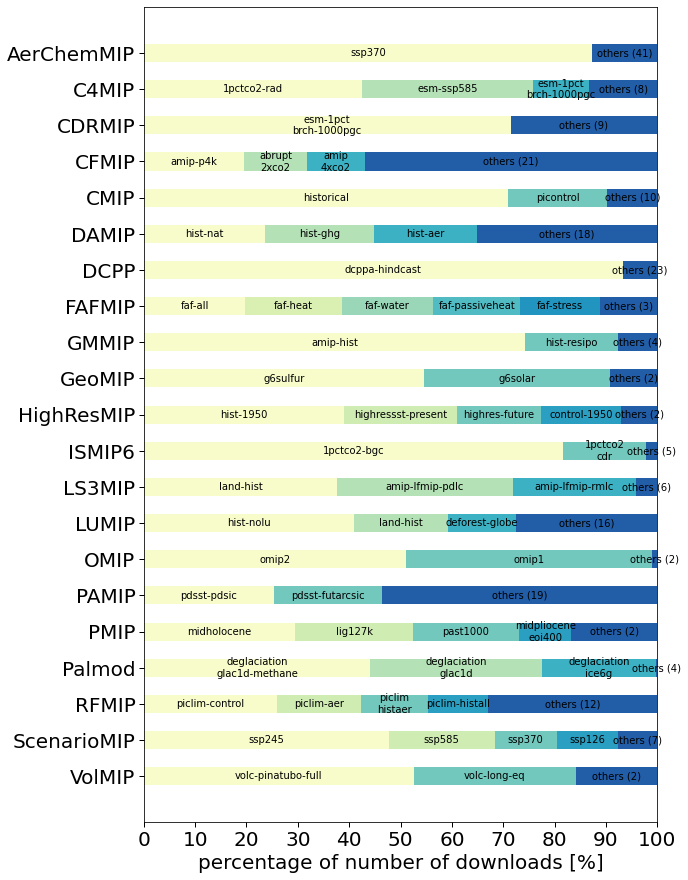

In [65]:
fig, ax = plt.subplots(figsize=(9.2, 15))
figname=plot_dir+'exp_per_mip_barh'
plotBar(ax,dict_mip,dfs_mip,label_rot=0)

fig.savefig(figname+'.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(figname+'.pdf',format='pdf', bbox_inches='tight',transparent=False)

plt.show()

In [19]:
results=dict_mip_size
exp_names=dfs_mip_size
labels = list(results.keys())
data = list(results.values())
data_cs, starts = [],[]
cmap = plt.get_cmap('YlGnBu')
category_colors = []
for d in data:
    tmp=d.cumsum()
    data_cs.append(tmp)
    category_colors.append([cmap(i) for i in np.linspace(0.05, 0.75, d.shape[0])])
    starts.append(tmp-d)


for i, (l,color,d,d_c,start,df) in enumerate(zip(labels,category_colors,data,data_cs,starts,dfs_mip)):
    if i==12:
        print(i, l, color, d,d_c,start,df['experiment_name'].values)
        print(df)


12 LS3MIP [(0.9734256055363322, 0.9896655132641292, 0.7919261822376009, 1.0), (0.7073125720876586, 0.8853056516724337, 0.7129873125720877, 1.0), (0.23497116493656298, 0.6932410611303347, 0.7664129181084199, 1.0), (0.13361014994232986, 0.3647520184544406, 0.6569780853517878, 1.0)] [0.23729045 0.35669714 0.25179864 0.15421377] [0.23729045 0.59398759 0.84578623 1.        ] [0.         0.23729045 0.59398759 0.84578623] ['land-hist' 'amip-lfmip-pdlc' 'amip-lfmip-rmlc' 'others (6)']
    experiment_name  number_of_downloads  total_size_GB Activity     % nod  \
46        land-hist               174481       10530.35   LS3MIP  0.376715   
50  amip-lfmip-pdlc               158264       14917.26   LS3MIP  0.341702   
61  amip-lfmip-rmlc               111022        9923.61   LS3MIP  0.239703   
0        others (6)                19397        6449.30   LS3MIP  0.041879   

      % tsGB  
46  0.251799  
50  0.356697  
61  0.237290  
0        NaN  


In [66]:
def plotBar_size(ax,results,exp_names,label_rot=0,xlabel_fs=20,barlabel_fs=10,xticks_fs=20,yticks_fs=20,hideYlabels=False):
    """
    Parameters
    ----------
    results : dict
        A mapping from question labels to a list of answers per category.
        It is assumed all lists contain the same number of entries and that
        it matches the length of *category_names*.
    category_names : list of str
        The category labels.
    """
    labels = list(results.keys())
    data = list(results.values())
    data_cs, starts = [],[]
    cmap = plt.get_cmap('YlGnBu')
    category_colors = []
    for d in data:
        tmp=d.cumsum()
        data_cs.append(tmp)
        category_colors.append([cmap(i) for i in np.linspace(0.05, 0.75, d.shape[0])])
        starts.append(tmp-d)

    ax.invert_yaxis()
    ax.set_xlim(0, 1)

    for i, (l,color,d,d_c,start,df) in enumerate(zip(labels,category_colors,data,data_cs,starts,exp_names)):
        rects = ax.barh(l, d, left=start, height=0.5,
                        label=l, color=color)
        ax.tick_params(axis="y",labelsize=yticks_fs, length=5, width=1, color ='black', direction='out')
        text_color = 'k'
        ax.set_xticks(np.arange(0,1.1,0.1))
        if hideYlabels==True:
            ax.set_yticklabels('')
        ax.set_xticklabels(range(0,110,10),fontsize=xticks_fs)
        ax.set_xlabel("percentage of size of downloads [%]",fontsize=xlabel_fs)
        ax.tick_params(axis='x', length=5, width=1, color ='black', direction='out')
        ax.bar_label(rects, labels=df['experiment_name'].values, label_type='center', color=text_color,rotation=label_rot,fontsize=barlabel_fs)
    #ax.legend(ncol=len(category_names), bbox_to_anchor=(0, 1),
    #          loc='lower left', fontsize='small')

    wrap_labels(ax,10)

    return fig, ax


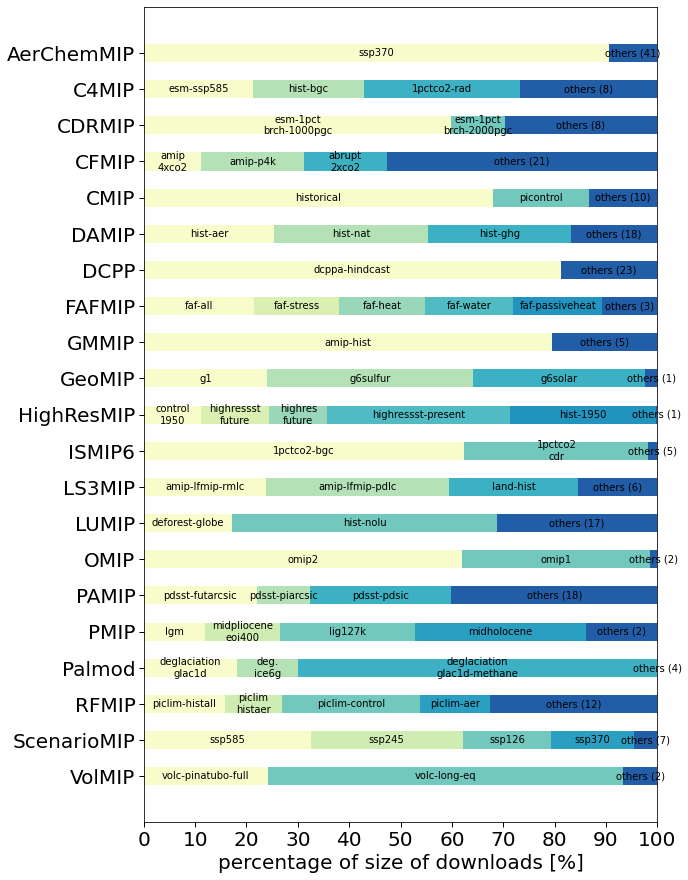

In [67]:
fig, ax = plt.subplots(figsize=(9.2, 15))
figname=plot_dir+'exp_per_mip_barh_download_size'
plotBar_size(ax,dict_mip_size,dfs_mip_size)
fig.savefig(figname+'.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(figname+'.pdf',format='pdf', bbox_inches='tight',transparent=False)

plt.show()

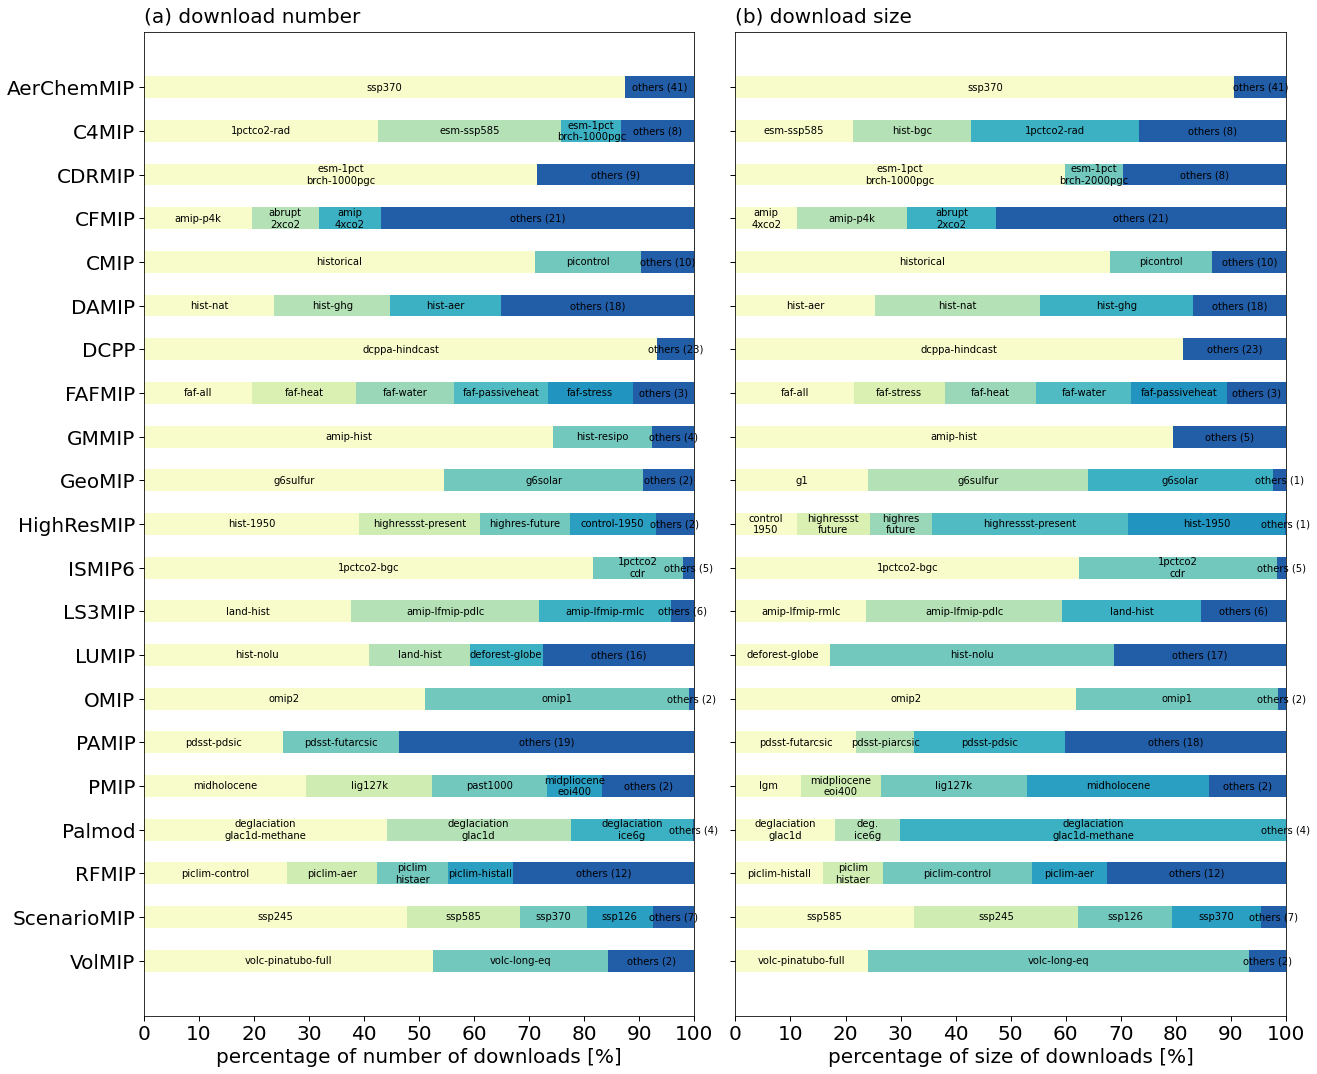

In [79]:
fig, ax = plt.subplots(ncols=2,nrows=1,figsize=(18.4, 15))
#figname=plot_dir+'exp_per_mip_barh_download_size'
plotBar(ax[0],dict_mip,dfs_mip,label_rot=0)
plotBar_size(ax[1],dict_mip_size,dfs_mip_size,hideYlabels=True)
#fig.savefig(figname+'.png', bbox_inches='tight',transparent=False,facecolor='white')
#fig.savefig(figname+'.pdf',format='pdf', bbox_inches='tight',transparent=False)
ax[0].text(0., 1.01, '(a) download number', transform = ax[0].transAxes,fontsize=20)
ax[1].text(0., 1.01, '(b) download size', transform = ax[1].transAxes,fontsize=20)
plt.tight_layout()

figname=plot_dir+'fig_exp_per_mip'
fig.savefig(figname+'.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(figname+'.pdf',format='pdf', bbox_inches='tight',transparent=False)

plt.show()

# Pie charts with contributions of experiments per MIP

Text(0.5, 1.0, 'GeoMIP')

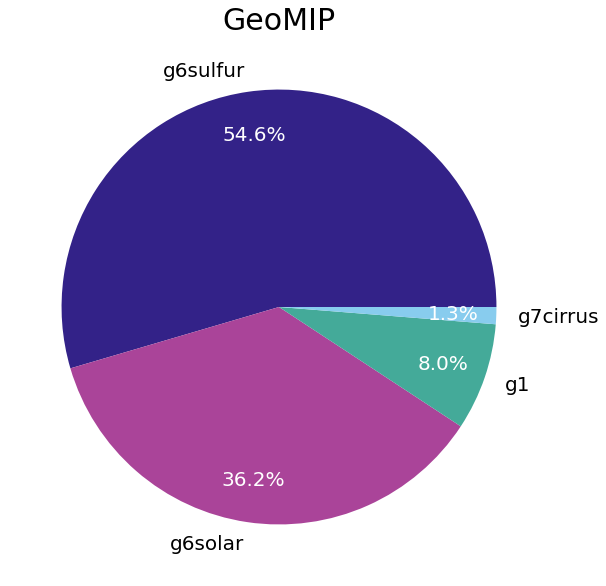

In [22]:
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
fig, ax = plt.subplots()
_,_,m=ax.pie(df_resort_split_orig.loc[(df_resort_split_orig['Activity'] == 'GeoMIP')]['number_of_downloads'], 
             labels=df_resort_split_orig.loc[(df_resort_split_orig['Activity'] == 'GeoMIP')]['experiment_name'], autopct='%1.1f%%',
             colors=['#332288', '#aa4499', '#44aa99', '#88ccee'],pctdistance=0.8,labeldistance=1.1,textprops=dict(fontsize=20))
[m[i].set_color('white') for i in range(len(m))]
ax.set_title('GeoMIP',fontsize=30,y=1.0)

Text(0.5, 1.0, 'ScenarioMIP')

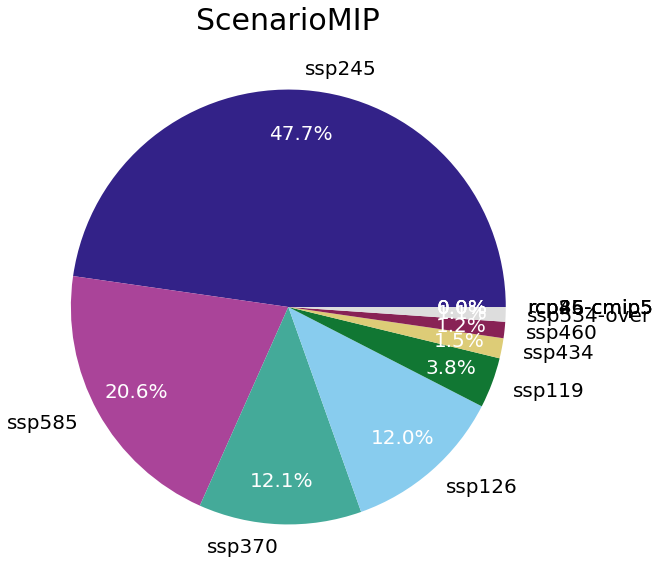

In [23]:
df_tmp = df_resort_split_orig.loc[(df_resort_split_orig['Activity'] == 'ScenarioMIP')]
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
fig, ax = plt.subplots()
_,_,m=ax.pie(df_tmp['number_of_downloads'], 
             labels=df_tmp['experiment_name'], autopct='%1.1f%%',
             colors=c_mip[:len(df_tmp.index)],pctdistance=0.8,labeldistance=1.1,textprops=dict(fontsize=20))
[m[i].set_color('white') for i in range(len(m))]
ax.set_title('ScenarioMIP',fontsize=30,y=1.0)

Text(0.5, 1.0, 'PMIP')

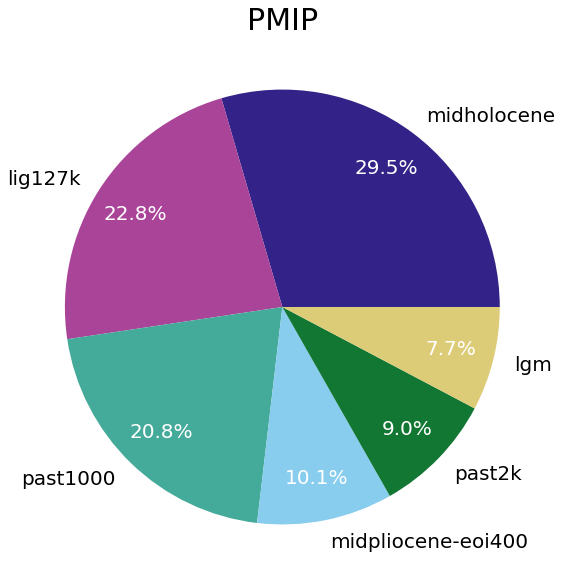

In [24]:
df_tmp = df_resort_split_orig.loc[(df_resort_split_orig['Activity'] == 'PMIP')]
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
fig, ax = plt.subplots()
_,_,m=ax.pie(df_tmp['number_of_downloads'], 
             labels=df_tmp['experiment_name'], autopct='%1.1f%%',
             colors=c_mip[:len(df_tmp.index)],pctdistance=0.8,labeldistance=1.1,textprops=dict(fontsize=20))
[m[i].set_color('white') for i in range(len(m))]
ax.set_title('PMIP',fontsize=30,y=1.0)

Text(0.5, 1.0, 'HighResMIP')

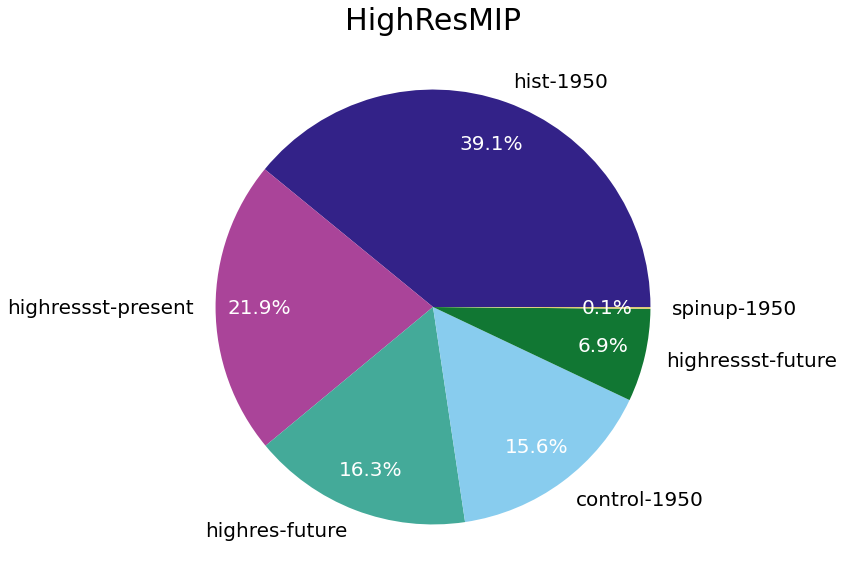

In [25]:
df_tmp = df_resort_split_orig.loc[(df_resort_split_orig['Activity'] == 'HighResMIP')]
matplotlib.rcParams['figure.figsize'] = (10.0, 10.0)
fig, ax = plt.subplots()
_,_,m=ax.pie(df_tmp['number_of_downloads'], 
             labels=df_tmp['experiment_name'], autopct='%1.1f%%',
             colors=c_mip[:len(df_tmp.index)],pctdistance=0.8,labeldistance=1.1,textprops=dict(fontsize=20))
[m[i].set_color('white') for i in range(len(m))]
ax.set_title('HighResMIP',fontsize=30,y=1.0)

In [26]:
mip_data = []
mip_data_sorted = []
for n in labels_mip:
    d = df_resort_split_orig.loc[(df_resort_split_orig['Activity'] == n)]
    df = d.sort_values(by=['number_of_downloads'],ascending=False)
    mip_data_sorted.append(df)
    if len(df.index) > 10:
        df2 = df[:9].copy()
        n_o = len(df[9:].index)
        new_row = pd.DataFrame(data = {'experiment_name' : ['others (n=%d)' % (n_o)],
                                       'number_of_downloads' : [df['number_of_downloads'][9:].sum()], 
                                       'total_size_GB': [df['total_size_GB'][9:].sum()], 
                                       'Activity' : [n]})
        df = pd.concat([df2,new_row])
    mip_data.append(df)

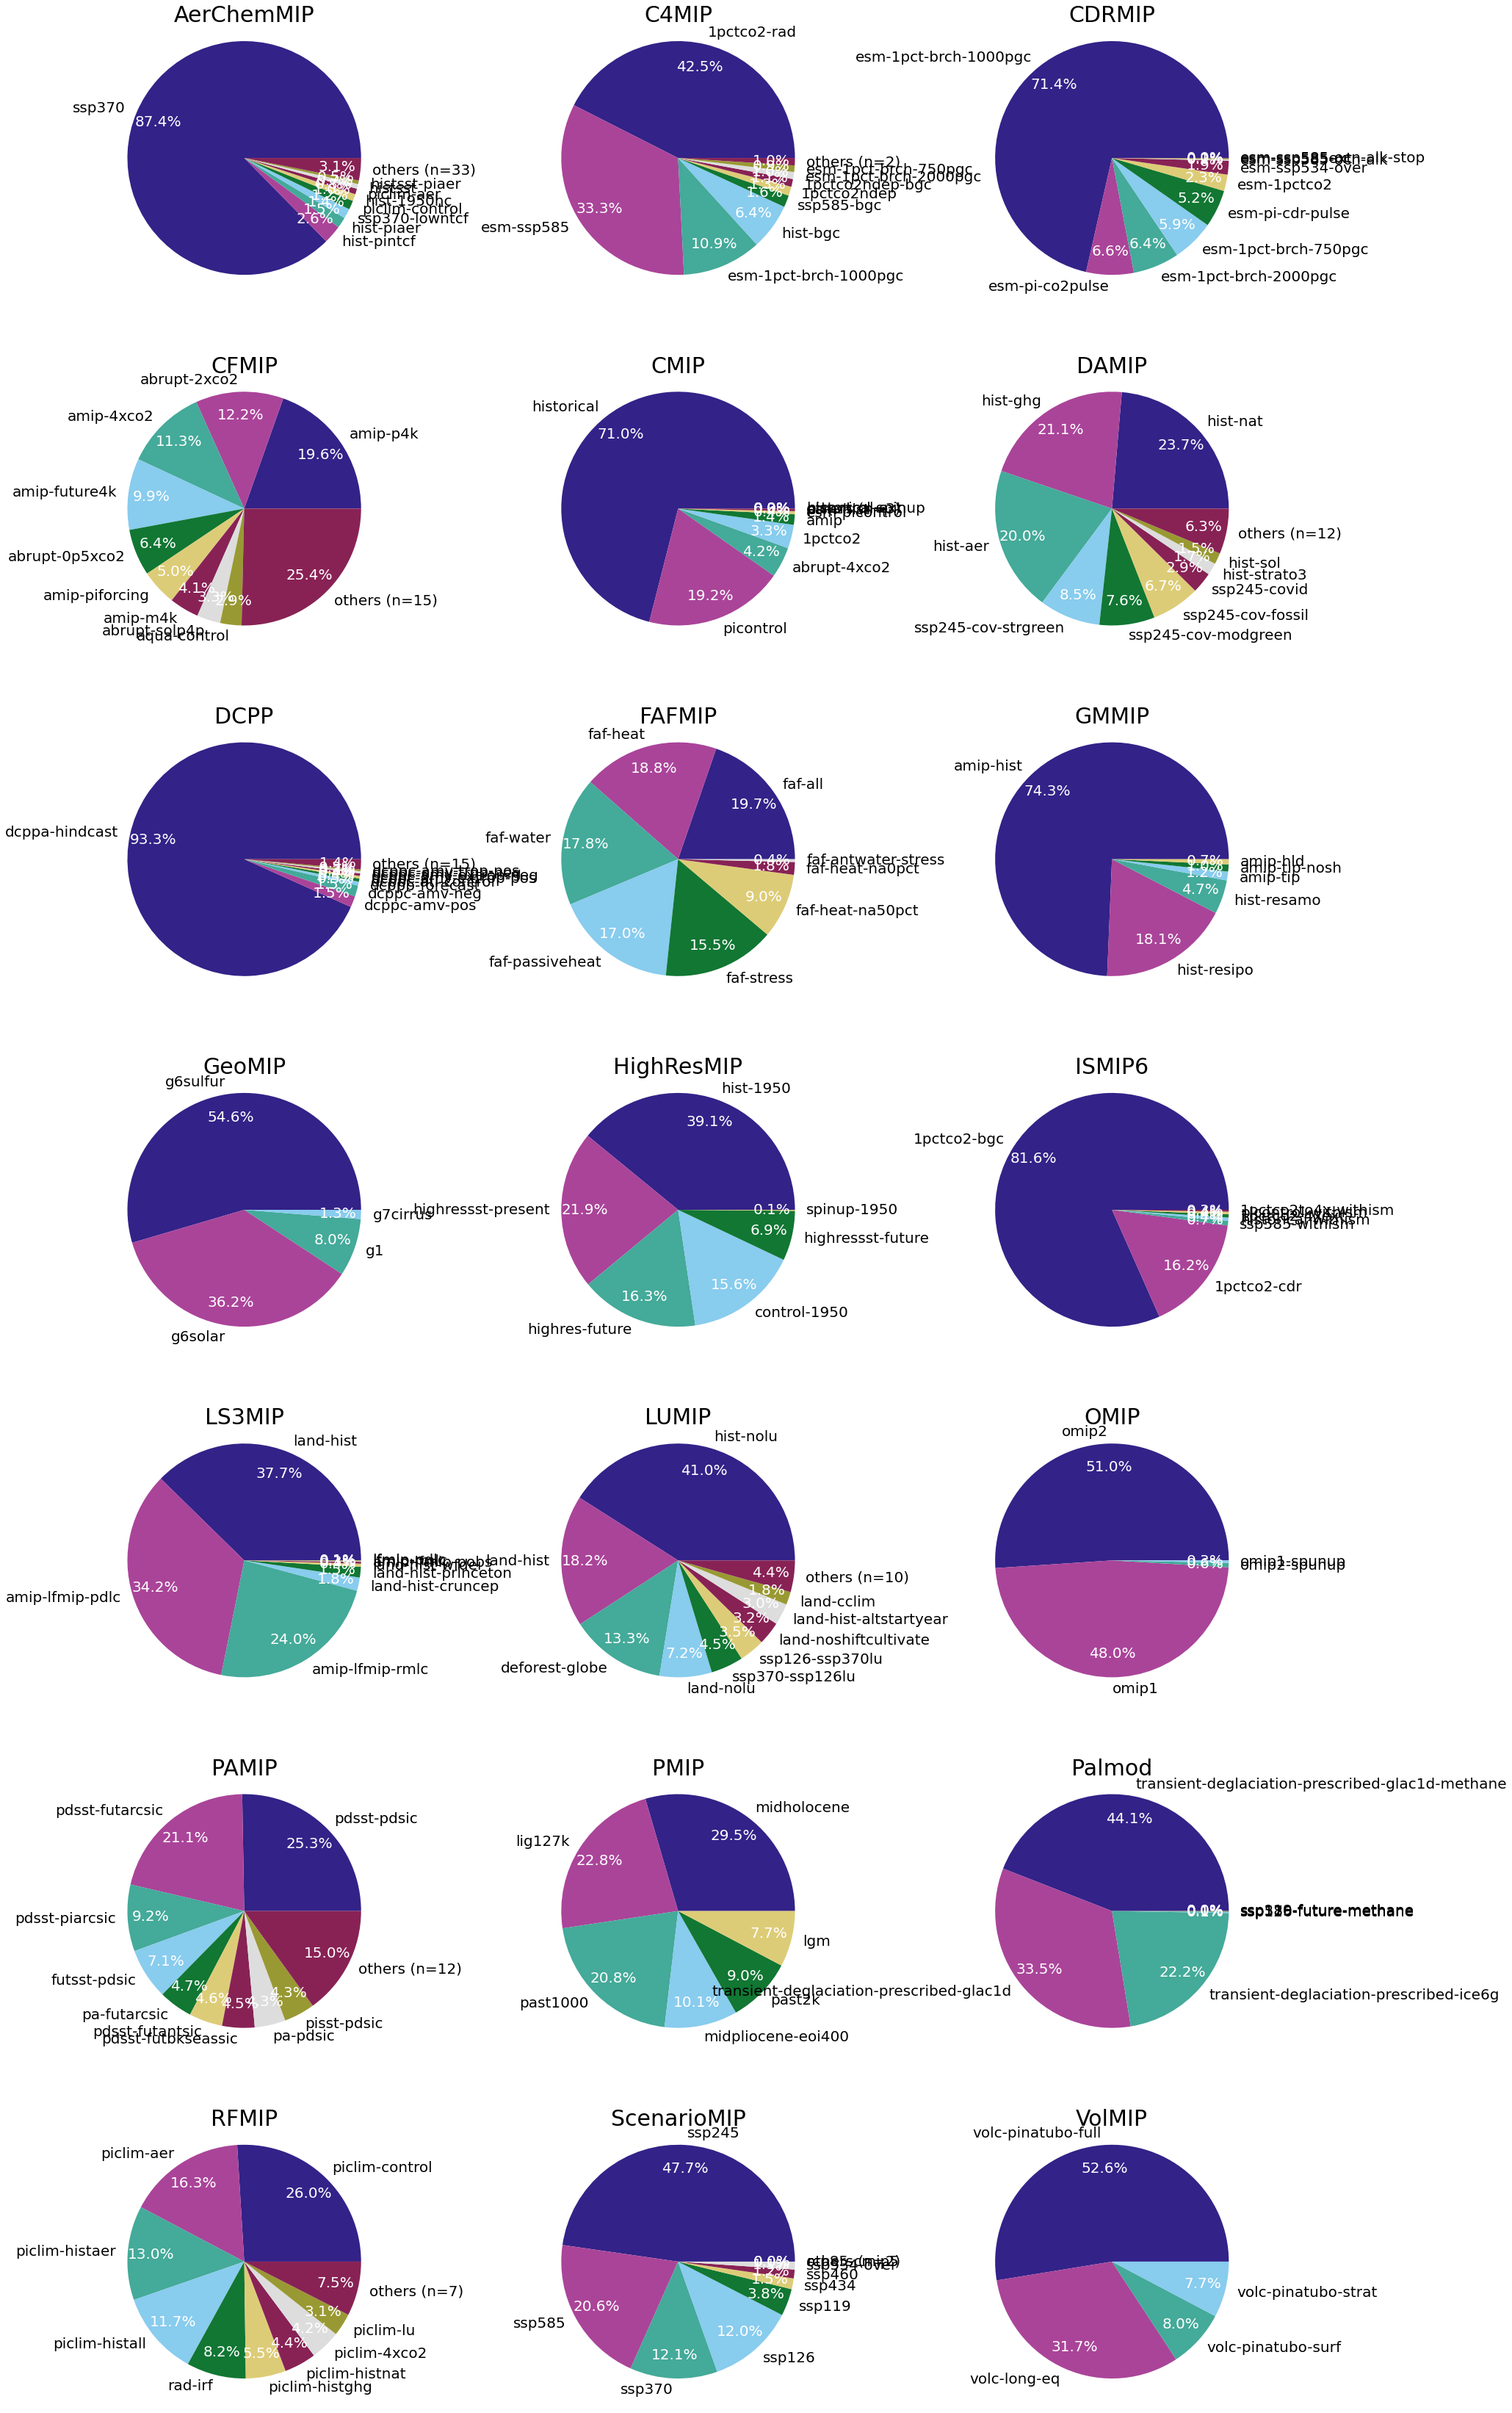

In [27]:
cols = 3
rows = 7
fig, axes = plt.subplots(ncols=cols,nrows=rows, figsize=(30,60))



for r in range(rows):
    for c in range(cols):
        dm = mip_data[r*cols+c]
        _,_,m = axes[r,c].pie(dm['number_of_downloads'], labels=dm['experiment_name'], autopct='%1.1f%%',
                              colors=c_mip[:len(dm.index)],pctdistance=0.8,labeldistance=1.1,
                              textprops=dict(fontsize=20))
        [m[i].set_color('white') for i in range(len(m))]
        axes[r,c].set_title(labels_mip[r*cols+c],y=0.95,fontsize=30)

fig.savefig(plot_dir+'exp_per_mip.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(plot_dir+'exp_per_mip.pdf',format='pdf', bbox_inches='tight',transparent=False)

# Bar plots with downloads per MIP

In [29]:
mip_sum = []
mip_nDown = []
mip_nSize = []
for n in labels_mip:
    tmp=df_expMIP.dropna()[df_expMIP.dropna()['Activity'].str.contains(n)].sum()
    tmp['Activity']=n
    mip_sum.append(tmp)
    mip_nDown.append(tmp['number_of_downloads'])
    mip_nSize.append(tmp['total_size_GB'])


In [30]:
df_mip_cmp = pd.DataFrame(
    {'mip_name': labels_mip,
     'number_of_downloads': mip_nDown,
     'total_size_TB': mip_nSize
    })

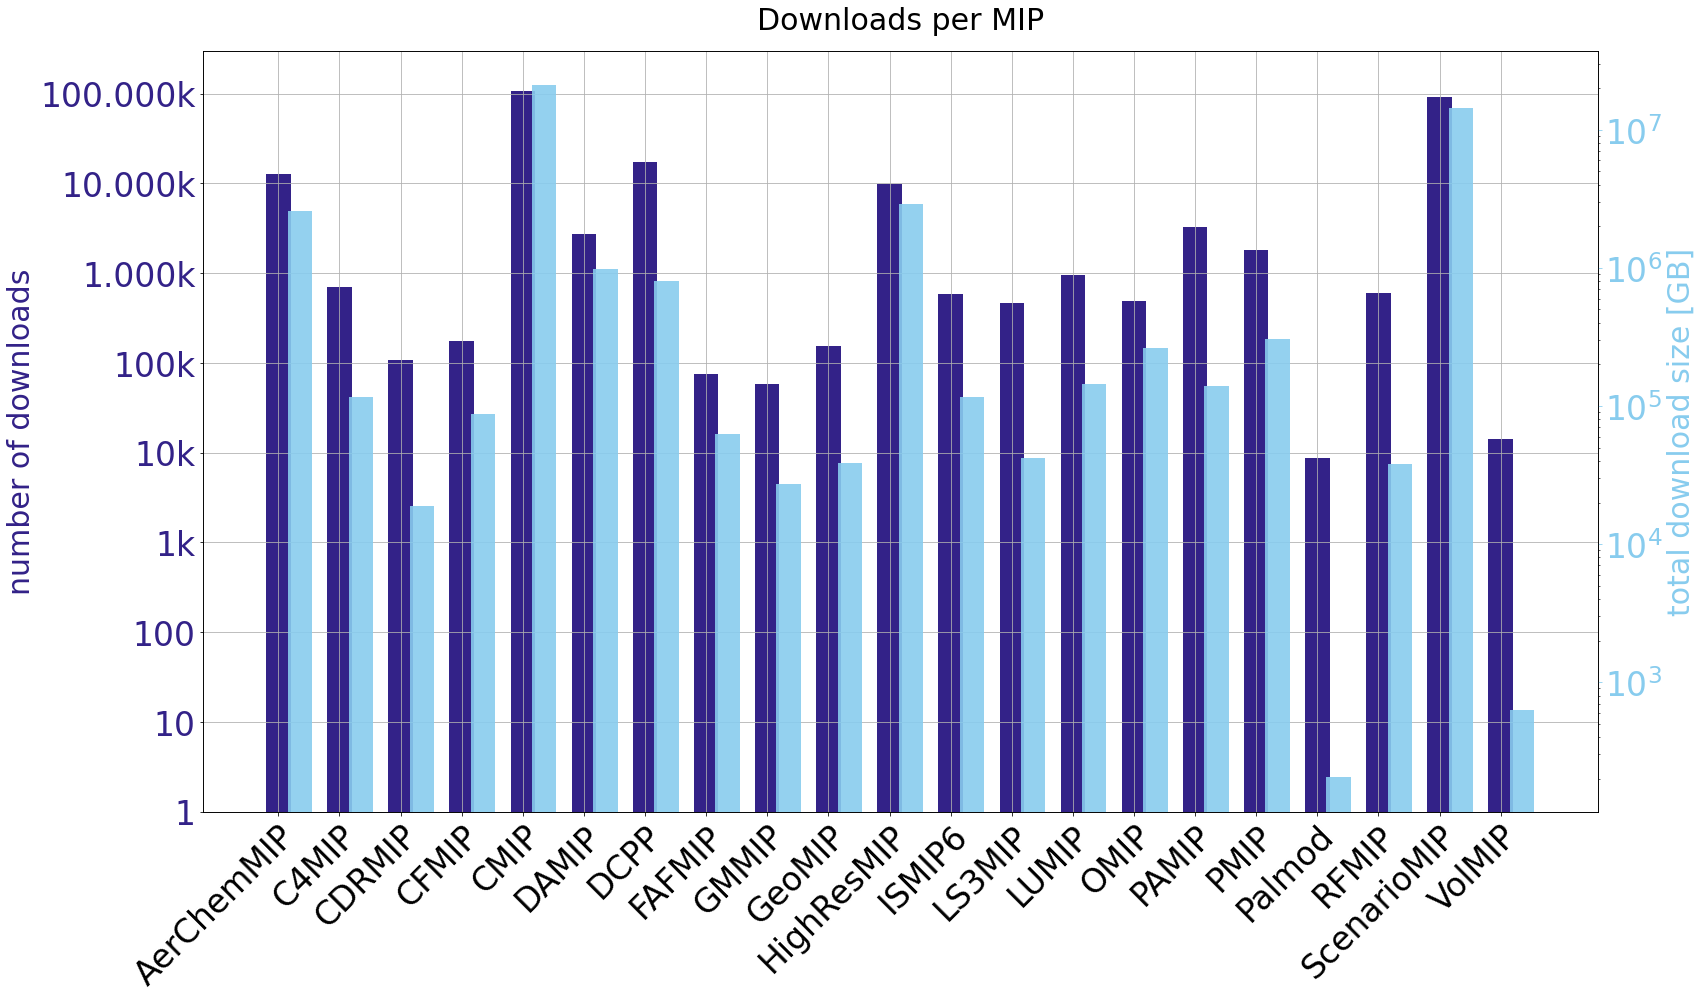

In [35]:
matplotlib.rcParams['figure.figsize'] = (25.0, 14.0)
fig, ax = plt.subplots()

ax.bar(range(0,len(labels_mip)*2,2),mip_nDown,color='#332288')
twin = ax.twinx()
twin.bar(np.asarray(range(0,len(labels_mip)*2,2))+0.7,mip_nSize,color='#88ccee',alpha=0.9)

ax.set_yscale('log')
twin.set_yscale('log')
#ax.set_xticklabels(['']*len(labels_mip))#, rotation=45, ha='right')
ax.set_xticks(range(0,len(labels_mip)*2,2))
ax.set_xticklabels(labels_mip,rotation=45, ha='right',rotation_mode='anchor')
ax.grid()
ax.set_ylim(1,3*10**8)
ax.set_title('Downloads per MIP',y=1.02,fontsize=30)
ax.set_ylabel('number of downloads',fontsize=30,color='#332288')
ax.set_yticks([1,10,100,1000,10**4,10**5,10**6,10**7,10**8])
ax.set_yticklabels([1,10,100,'1k','10k','100k','1.000k','10.000k','100.000k'],color='#332288')
twin.set_ylabel('total download size [GB]',fontsize=30,color='#88ccee')
twin.tick_params(axis='y', colors='#88ccee')
ax.set_yticklabels([1,10,100,'1k','10k','100k','1.000k','10.000k','100.000k'],color='#332288')


#for xi, yi, text in zip(range(0,len(labels_mip)*2,2), mip_nDown, labels_mip):
#    twin.annotate(text,xy=(xi, yi), xycoords='data',xytext=(2.5, 2.5), textcoords='offset points', fontsize=30)

fig.savefig(plot_dir+'downloads_per_mip_bar_log.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(plot_dir+'downloads_per_mip_bar_log.pdf',format='pdf', bbox_inches='tight',transparent=False)

In [33]:
mip_nDown

[12592773,
 696327,
 106571,
 174357,
 105520984,
 2703405,
 17094045,
 75383,
 58022,
 153112,
 9942445,
 589798,
 463164,
 958562,
 487209,
 3293976,
 1806620,
 8788,
 599050,
 90907691,
 14326]

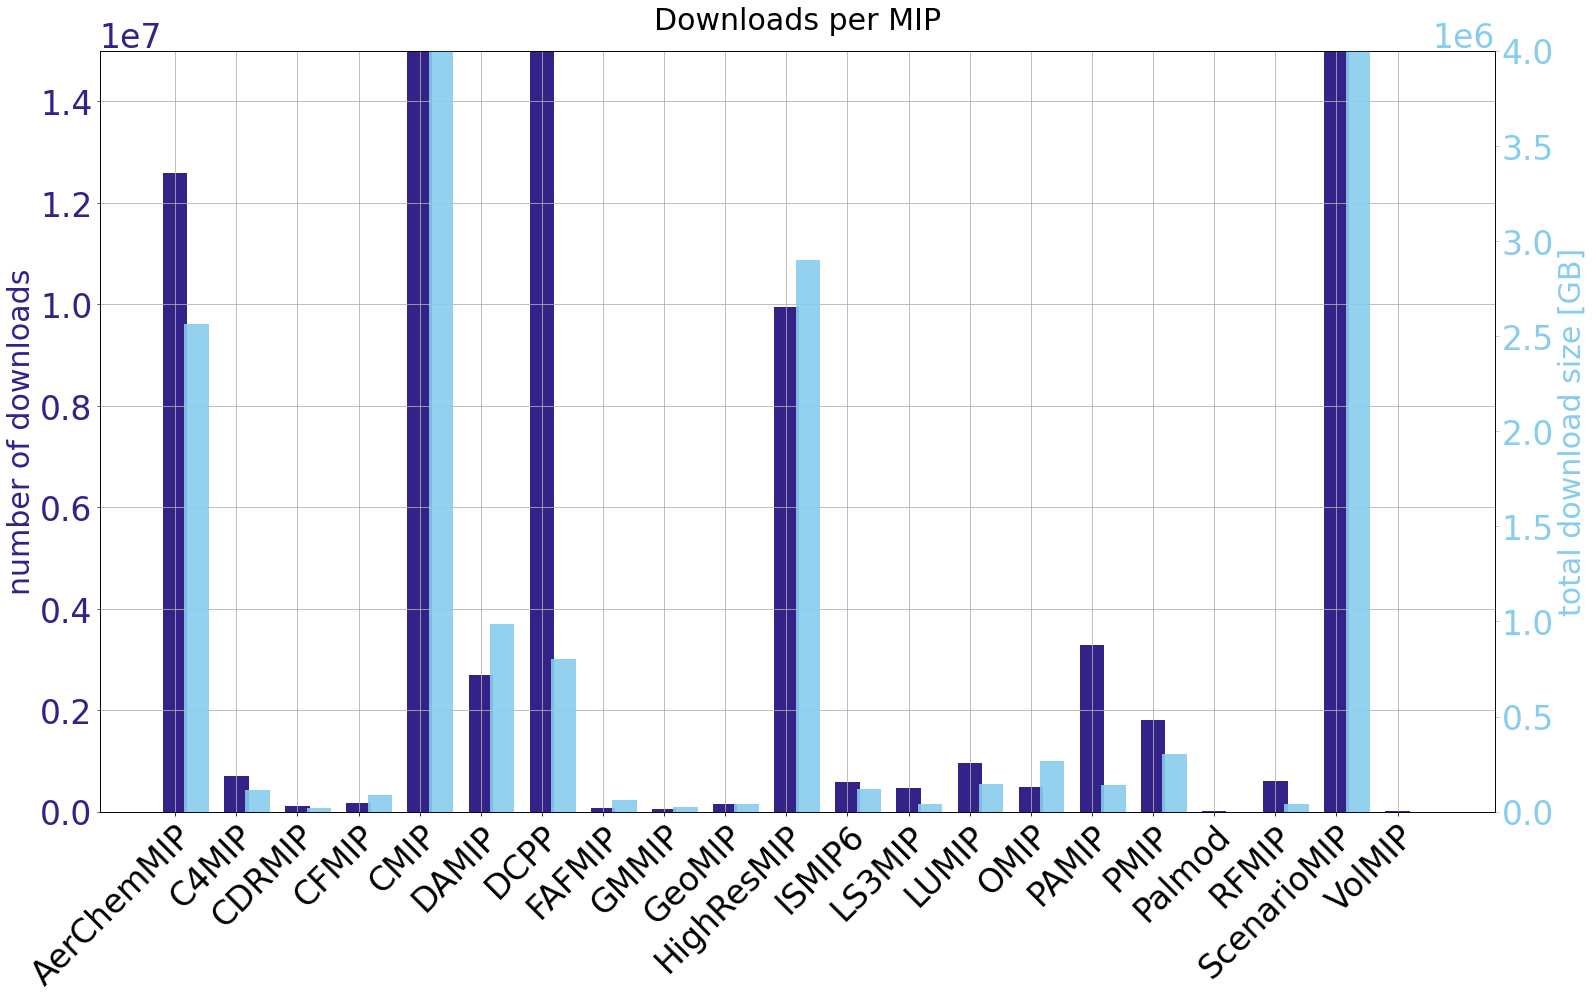

In [40]:
matplotlib.rcParams['figure.figsize'] = (25.0, 14.0)
fig, ax = plt.subplots()

ax.bar(range(0,len(labels_mip)*2,2),df_mip_cmp['number_of_downloads'],color='#332288')
twin = ax.twinx()
twin.bar(np.asarray(range(0,len(labels_mip)*2,2))+0.7,df_mip_cmp['total_size_TB'],color='#88ccee',alpha=0.9)

#ax.set_xticklabels(['']*len(labels_mip))#, rotation=45, ha='right')
ax.set_xticks(range(0,len(labels_mip)*2,2))
ax.set_xticklabels(df_mip_cmp['mip_name'],rotation=45, ha='right', rotation_mode='anchor')
ax.grid()
ax.set_ylim(0,1.5*10**7)
ax.set_title('Downloads per MIP',y=1.02,fontsize=30)
ax.set_ylabel('number of downloads',fontsize=30,color='#332288')
ax.tick_params(axis='y', colors='#332288')
twin.set_ylabel('total download size [GB]',fontsize=30,color='#88ccee')
twin.tick_params(axis='y', colors='#88ccee')
twin.set_ylim(0,0.4*10**7)


#for xi, yi, text in zip(range(0,len(labels_mip)*2,2), mip_nDown, labels_mip):
#    twin.annotate(text,xy=(xi, yi), xycoords='data',xytext=(2.5, 2.5), textcoords='offset points', fontsize=30)

fig.savefig(plot_dir+'downloads_per_mip_bar.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(plot_dir+'downloads_per_mip_bar.pdf',format='pdf', bbox_inches='tight',transparent=False)

In [37]:
df_mip_cmp_resort=df_mip_cmp.sort_values(by=['number_of_downloads'],ascending=False)


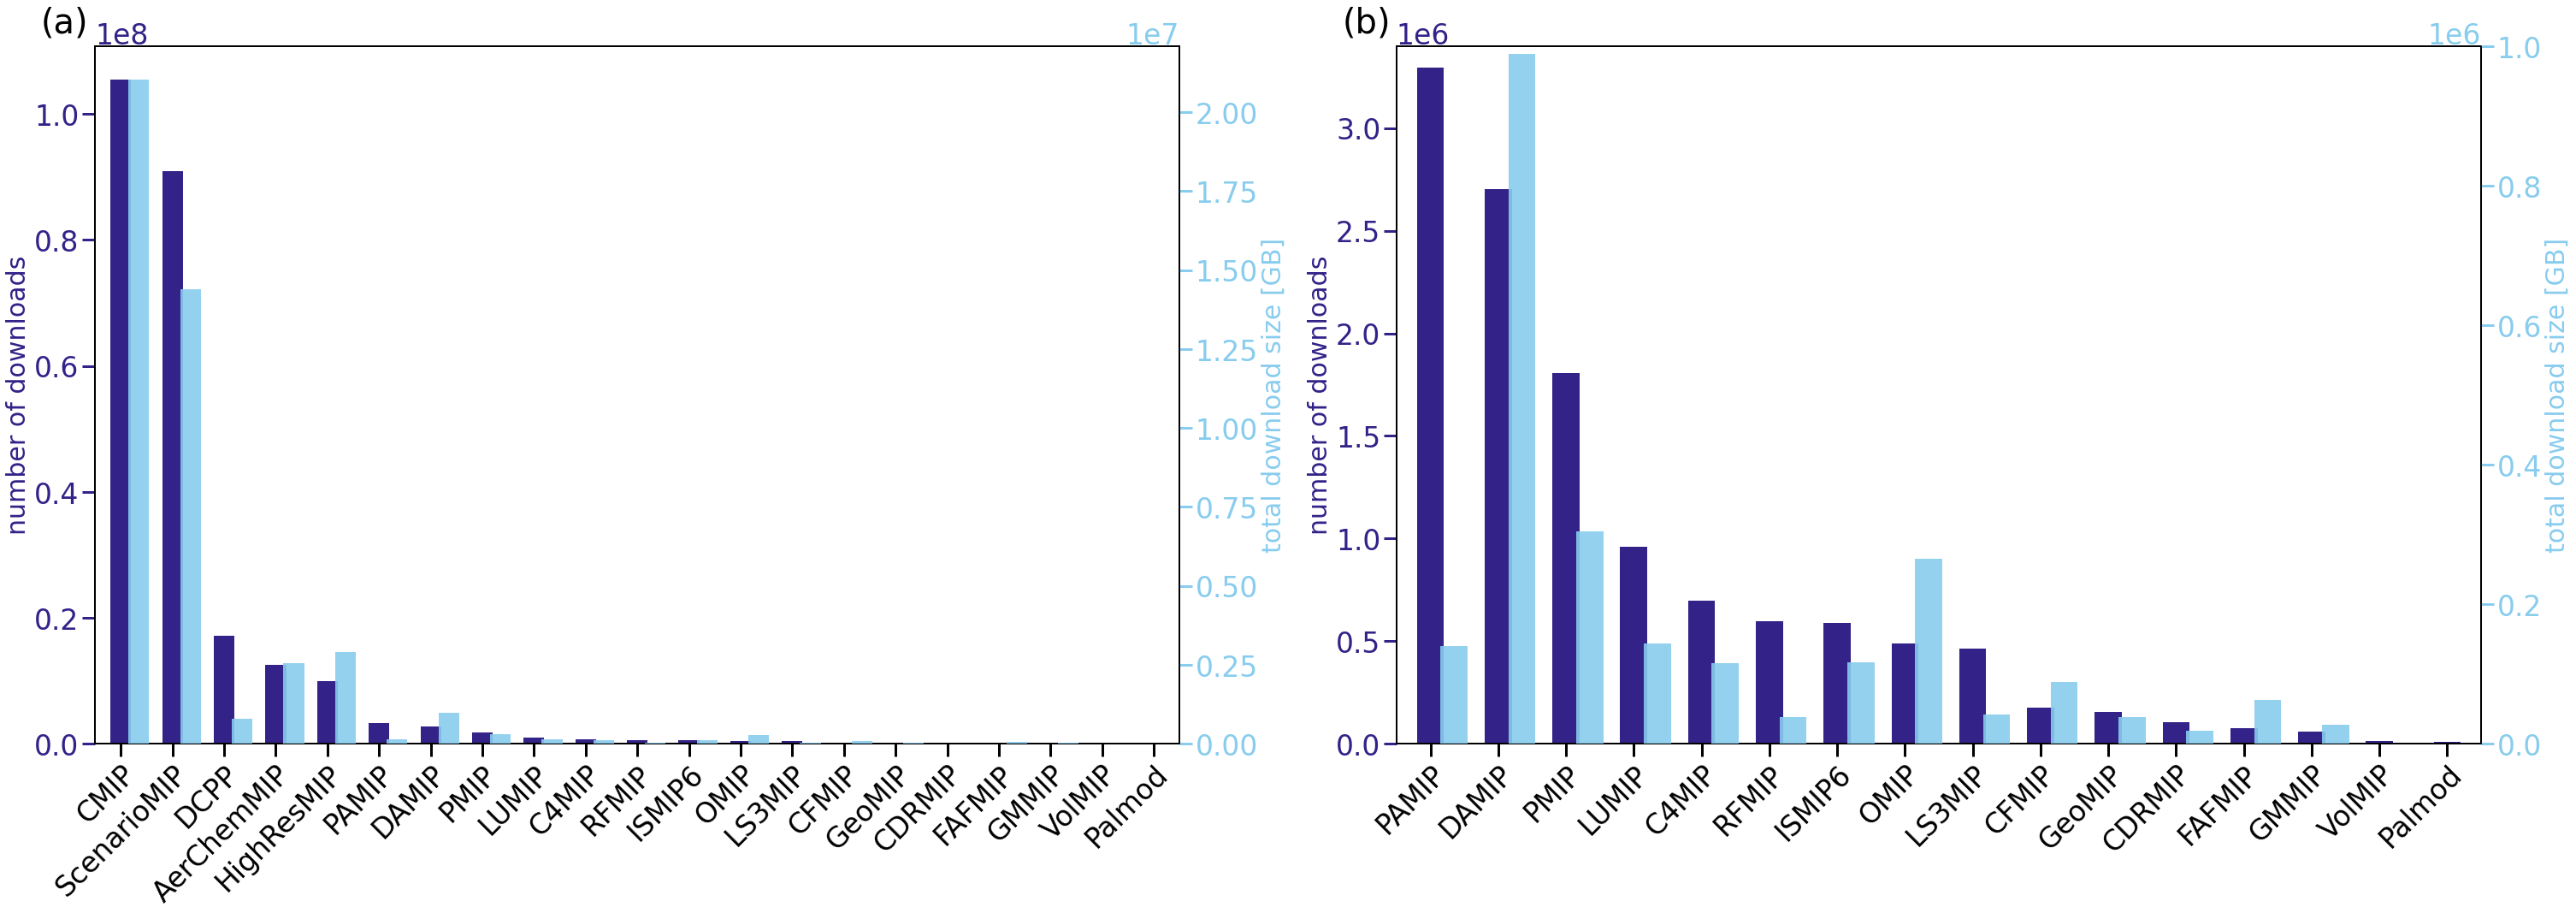

In [41]:
matplotlib.rcParams['figure.figsize'] = (50.0, 15.0)
fig, ax = plt.subplots(nrows=1,ncols=2)

ax[0].bar(range(0,len(labels_mip)*2,2),df_mip_cmp_resort['number_of_downloads'],color='#332288')
twin = ax[0].twinx()
twin.bar(np.asarray(range(0,len(labels_mip)*2,2))+0.7,df_mip_cmp_resort['total_size_TB'],color='#88ccee',alpha=0.9)

#ax[0].set_xticklabels(['']*len(labels_mip))#, rotation=45, ha='right')
ax[0].set_xticks(range(0,len(labels_mip)*2,2))
ax[0].set_xticklabels(df_mip_cmp_resort['mip_name'],rotation=45, ha='right', rotation_mode='anchor')
#ax[0].grid()
ax[0].set_xlim(-1,41)
#ax[0].set_title('Downloads per MIP',y=1.02,fontsize=30)
ax[0].set_ylabel('number of downloads',fontsize=30,color='#332288')
ax[0].tick_params(axis='y', colors='#332288', width=3, length=15)
ax[0].tick_params(axis='x', width=3, length=15)
twin.set_ylabel('total download size [GB]',fontsize=30,color='#88ccee')
twin.tick_params(axis='y', colors='#88ccee', width=3, length=15)
#twin.set_ylim(0,0.4*10**7)
ax[0].spines['top'].set_linewidth(2)
ax[0].spines['left'].set_linewidth(2)
ax[0].spines['right'].set_linewidth(2)
ax[0].spines['bottom'].set_linewidth(2)
ax[0].text(-0.05, 1.02,'(a)', fontsize=40,zorder=15, transform = ax[0].transAxes)

# Zoom panel for shorter ones
start_idx = 5
ax[1].bar(range(0,len(labels_mip[start_idx:])*2,2),df_mip_cmp_resort[start_idx:]['number_of_downloads'],color='#332288')
twin = ax[1].twinx()
twin.bar(np.asarray(range(0,len(labels_mip[start_idx:])*2,2))+0.7,df_mip_cmp_resort[start_idx:]['total_size_TB'],color='#88ccee',alpha=0.9)

#ax[1].set_xticklabels(['']*len(labels_mip))#, rotation=45, ha='right')
ax[1].set_xticks(range(0,len(labels_mip[start_idx:])*2,2))
ax[1].set_xticklabels(df_mip_cmp_resort[start_idx:]['mip_name'],rotation=45, ha='right', rotation_mode='anchor')
#ax[1].grid()
ax[1].set_ylim(0,0.34*10**7)
ax[1].set_xlim(-1,31)
#ax[1].set_title('Downloads per MIP',y=1.02,fontsize=30)
ax[1].set_ylabel('number of downloads',fontsize=30,color='#332288')
ax[1].tick_params(axis='y', colors='#332288', width=3, length=15)
ax[1].tick_params(axis='x', width=3, length=15)
twin.set_ylabel('total download size [GB]',fontsize=30,color='#88ccee')
twin.tick_params(axis='y', colors='#88ccee', width=3, length=15)
twin.set_ylim(0,1.0*10**6)
ax[1].spines['top'].set_linewidth(2)
ax[1].spines['left'].set_linewidth(2)
ax[1].spines['right'].set_linewidth(2)
ax[1].spines['bottom'].set_linewidth(2)
ax[1].text(-0.05, 1.02,'(b)', fontsize=40,zorder=15, transform = ax[1].transAxes)

plt.subplots_adjust(wspace=0.2)

fig.savefig(plot_dir+'fig_mipDownloads.png', bbox_inches='tight',transparent=False,facecolor='white')
fig.savefig(plot_dir+'fig_mipDownloads.pdf',format='pdf', bbox_inches='tight',transparent=False)

# Downloads per experiments across MIP

/tmp/ipykernel_11360/3884020053.py:6: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_xticklabels(['']*len(labels_mip), rotation=45, ha='right')


Text(0, 0.5, '# downloads')

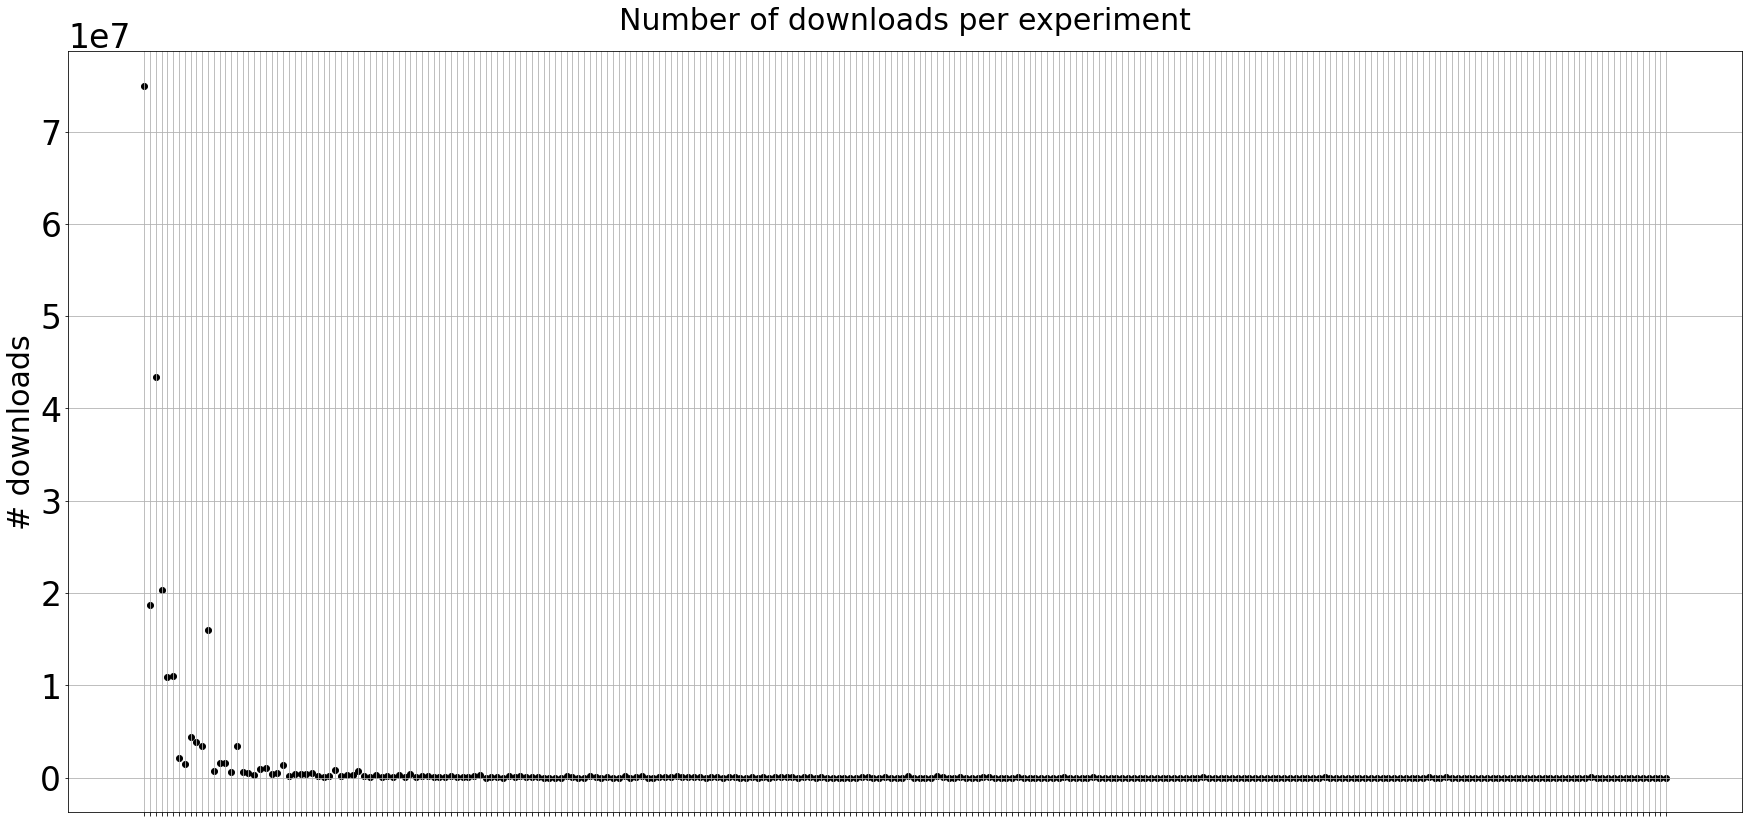

In [42]:
matplotlib.rcParams['figure.figsize'] = (30.0, 14.0)
fig, ax = plt.subplots()

ax.scatter(df_expMIP.dropna()['experiment_name'],df_expMIP.dropna()['number_of_downloads'],color='k')
#ax.set_yscale('log')
ax.set_xticklabels(['']*len(labels_mip), rotation=45, ha='right')
ax.grid()
#ax.set_ylim(1,3*10**8)
ax.set_title('Number of downloads per experiment',y=1.02,fontsize=30)
ax.set_ylabel('# downloads',fontsize=30)
#ax.set_yticks([1,10,100,1000,10**4,10**5,10**6,10**7,10**8])
#ax.set_yticklabels([1,10,100,'1k','10k','100k','1.000k','10.000k','100.000k'])


#for xi, yi, text in zip(labels_mip, mip_nDown, labels_mip):
#    ax.annotate(text,xy=(xi, yi), xycoords='data',xytext=(2.5, 2.5), textcoords='offset points', fontsize=30)

#fig.savefig(plot_dir+'downNum_per_mip_lim.png', bbox_inches='tight',transparent=False,facecolor='white')
#fig.savefig(plot_dir+'downNum_per_mip_lim.pdf',format='pdf', bbox_inches='tight',transparent=False)

In [43]:
df_expMIP_sort1=df_expMIP.dropna().sort_values(by=['number_of_downloads'],ascending=False)
df_expMIP_sort2=df_expMIP.dropna().sort_values(by=['total_size_GB'],ascending=False)


In [44]:
# TOP 10 MOST DOWNLOADED
df_expMIP_sort1[:10]

,experiment_name,number_of_downloads,total_size_GB,Activity
0,historical,74948855,14301053.92,CMIP
2,ssp245,43389071,4272423.51,ScenarioMIP
3,picontrol,20309730,3931228.96,CMIP
1,ssp585,18729733,4676138.99,ScenarioMIP
11,dcppa-hindcast,15948090,652159.32,DCPP
5,ssp370,11002427,2323535.11,"ScenarioMIP, AerChemMIP"
4,ssp126,10923775,2475419.44,ScenarioMIP
8,abrupt-4xco2,4460393,903344.43,CMIP
9,hist-1950,3885627,827898.75,HighResMIP
10,1pctco2,3451781,717789.12,CMIP


In [45]:
# TOP 10 LEAST DOWNLOADED
df_expMIP_sort1[-10:]

,experiment_name,number_of_downloads,total_size_GB,Activity
245,esm-ssp585ext,157,38.62,CDRMIP
259,piclim-spaer-histall,155,8.87,RFMIP
260,piclim-spaer-histaer,102,7.85,RFMIP
248,histsst-nolu,86,31.42,AerChemMIP
244,picontrol-cmip5,67,39.76,CMIP
258,esm-ssp585-ocn-alk-stop,41,12.67,CDRMIP
266,ssp126-future-methane,13,0.01,Palmod
267,ssp370-future-methane,6,0.01,Palmod
265,ssp585-future-methane,4,0.02,Palmod
268,ssp119-future-methane,1,0.01,Palmod


In [46]:
# TOP 10 BY DOWNLOAD SIZE
df_expMIP_sort2[:10]

,experiment_name,number_of_downloads,total_size_GB,Activity
0,historical,74948855,14301053.92,CMIP
1,ssp585,18729733,4676138.99,ScenarioMIP
2,ssp245,43389071,4272423.51,ScenarioMIP
3,picontrol,20309730,3931228.96,CMIP
4,ssp126,10923775,2475419.44,ScenarioMIP
5,ssp370,11002427,2323535.11,"ScenarioMIP, AerChemMIP"
6,highressst-present,2180322,1030513.58,HighResMIP
7,amip,1527968,984812.30,CMIP
8,abrupt-4xco2,4460393,903344.43,CMIP
9,hist-1950,3885627,827898.75,HighResMIP


In [47]:
# TOP 10 LEAST DOWNLOADED BY DOWNLOAD SIZE
df_expMIP_sort2[-10:]

,experiment_name,number_of_downloads,total_size_GB,Activity
256,rcp45-cmip5,187,14.05,ScenarioMIP
257,rcp26-cmip5,187,12.89,ScenarioMIP
258,esm-ssp585-ocn-alk-stop,41,12.67,CDRMIP
259,piclim-spaer-histall,155,8.87,RFMIP
260,piclim-spaer-histaer,102,7.85,RFMIP
261,dcppc-atl-spg,680,2.93,DCPP
265,ssp585-future-methane,4,0.02,Palmod
266,ssp126-future-methane,13,0.01,Palmod
267,ssp370-future-methane,6,0.01,Palmod
268,ssp119-future-methane,1,0.01,Palmod
